# FMPE Normalization Benchmark — Analysis

Load pre-computed results from `results/` and visualise all figures.
No GPU or JAX required — this notebook is pure matplotlib.

**Run the experiments first:**
```bash
python main.py                                          # local, small model
python main.py --hidden 128 512 1024 512 128 --batch_size 256  # GPU / Colab
```


## 1 — Load results


In [2]:
from utils import (
    load_results,
    plot_results,
    plot_lipschitz_curves,
    plot_nfe_vs_tolerance_from_data,
)

RESULTS_DIR = "results"
TASKS       = ["two_moons"]

data = {}
for task in TASKS:
    metrics, lip, nfe_tol, config = load_results(RESULTS_DIR, task)
    data[task] = dict(metrics=metrics, lip=lip, nfe_tol=nfe_tol)
    print(f"{task}: budgets={config['budgets']}, seeds={config['seeds']}, hidden={config['hidden_sizes']}") 


two_moons: budgets=[1000, 10000, 100000], seeds=[1, 2, 3, 4, 5], hidden=[64, 128, 256, 128, 64]


## 2 — Benchmark results: C2ST / NFE / inference time

3 × 3 grid per task: rows = normalization, columns = C2ST / NFE / inference time.
Lines = ODE tolerances; shading = min–max over seeds.



── two_moons ──


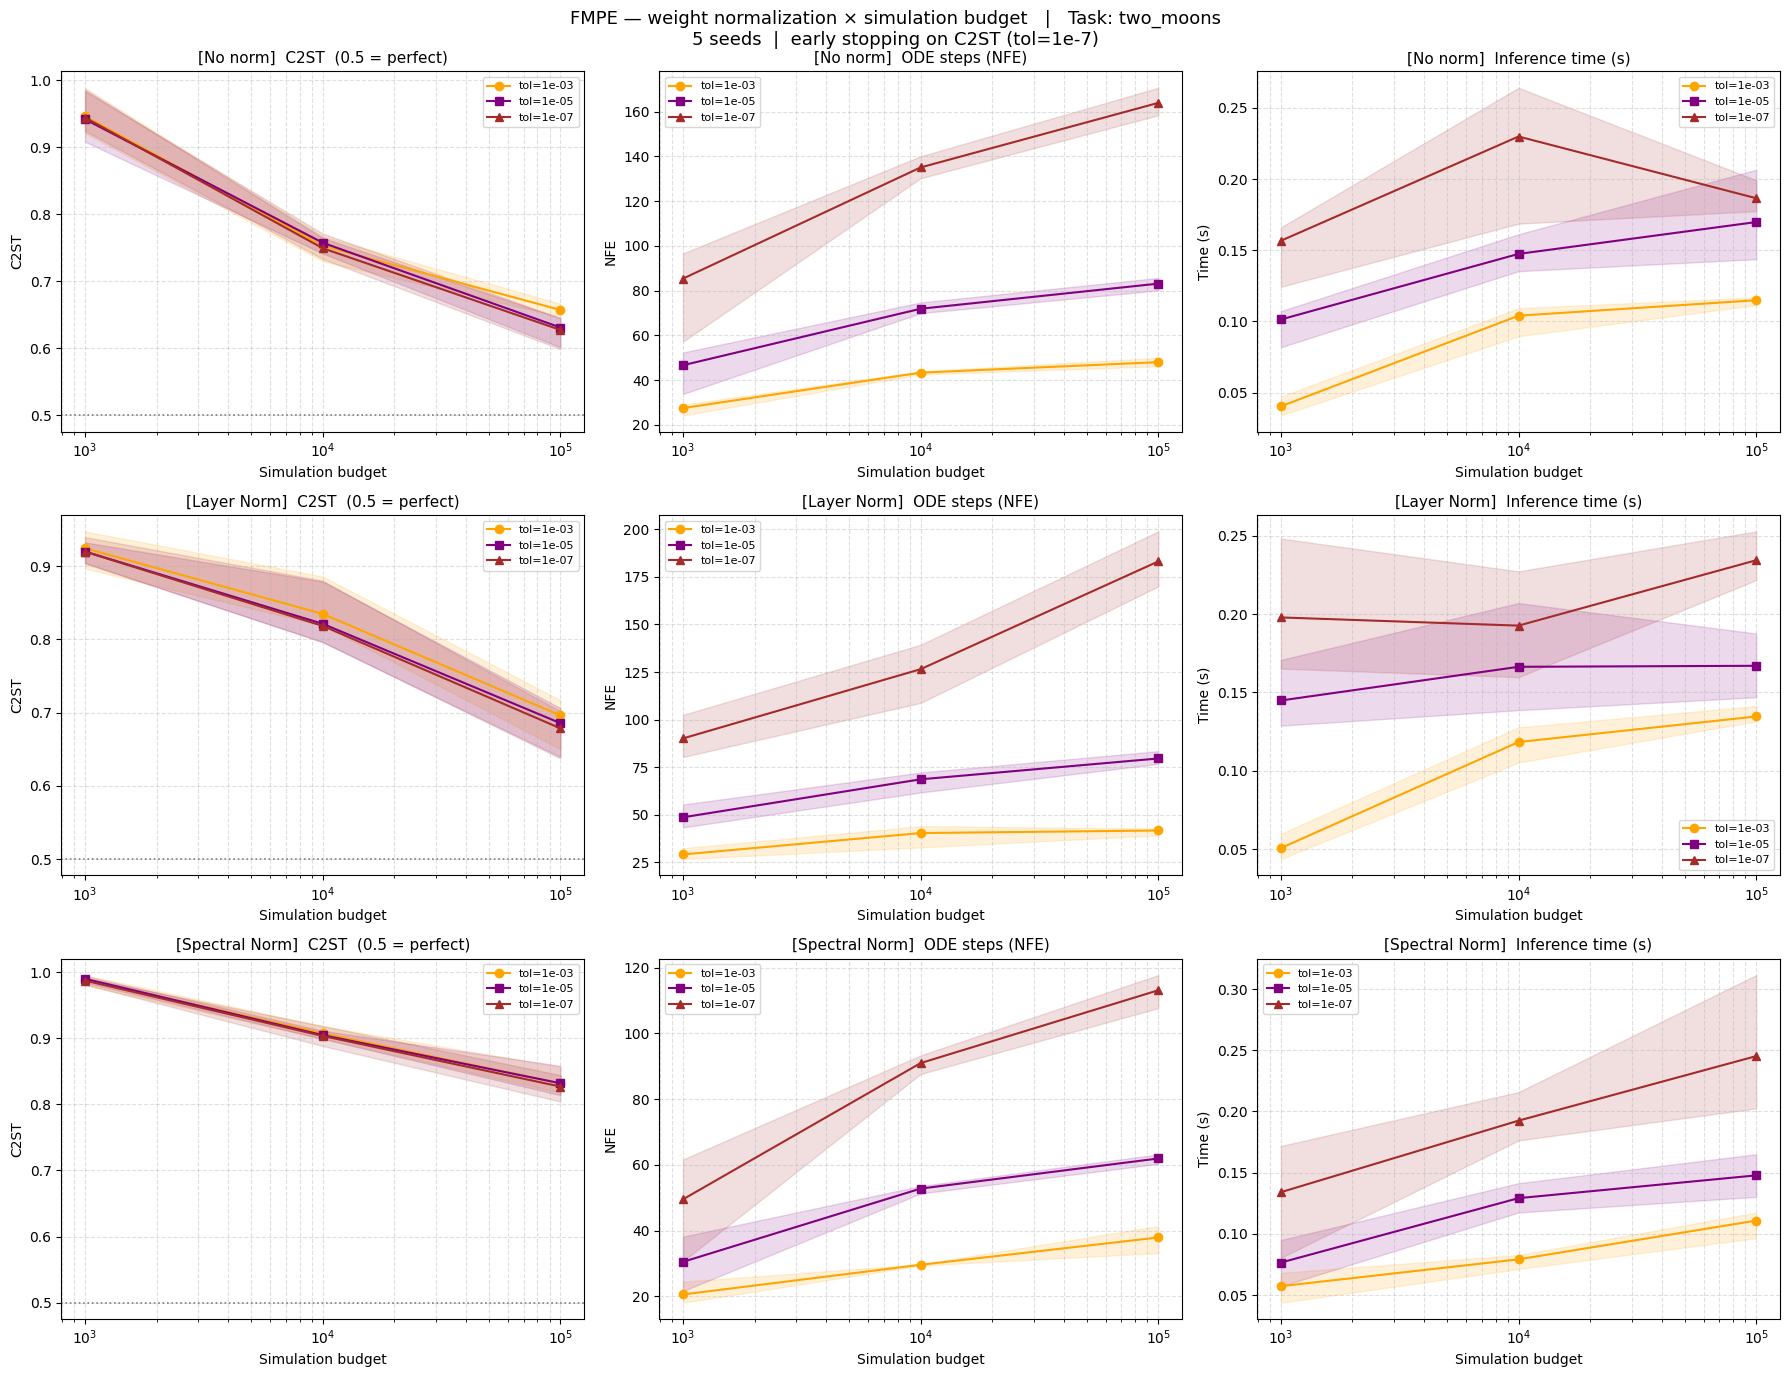

In [3]:
for task in TASKS:
    print(f"\n── {task} ──")
    plot_results(data[task]["metrics"], config["budgets"], task_name=task)


## 3 — Lipschitz constant over training

Empirical $\hat{L}$ of $v_\phi(t{=}0.5, \cdot, x_\text{obs})$ throughout training.
Spectral norm keeps $\hat{L}\approx 1$ by construction.



── two_moons ──


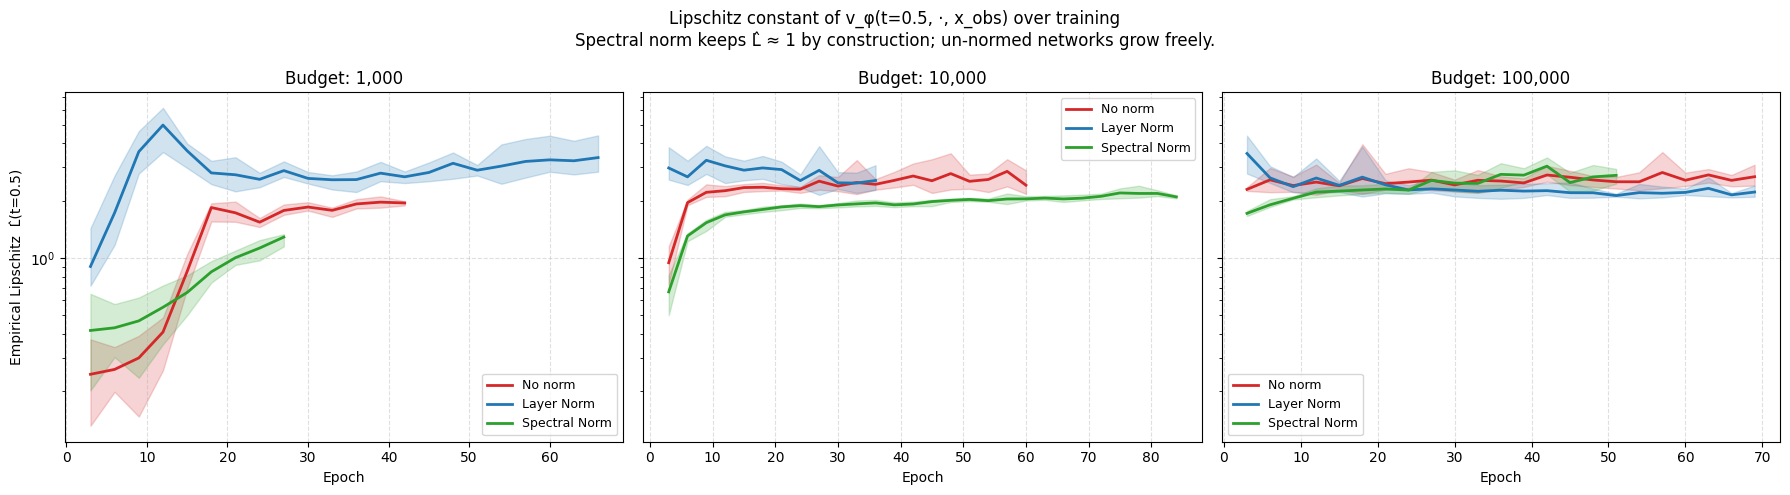

In [4]:
for task in TASKS:
    print(f"\n── {task} ──")
    plot_lipschitz_curves(data[task]["lip"], config["budgets"], eval_freq=config["eval_freq"])


## 4 — ODE stiffness: NFE vs tolerance

Sweep from loose ($10^{-2}$) to tight ($10^{-7}$) tolerance.
A Lipschitz-bounded vector field → smoother ODE → NFE grows more slowly.



── two_moons ──


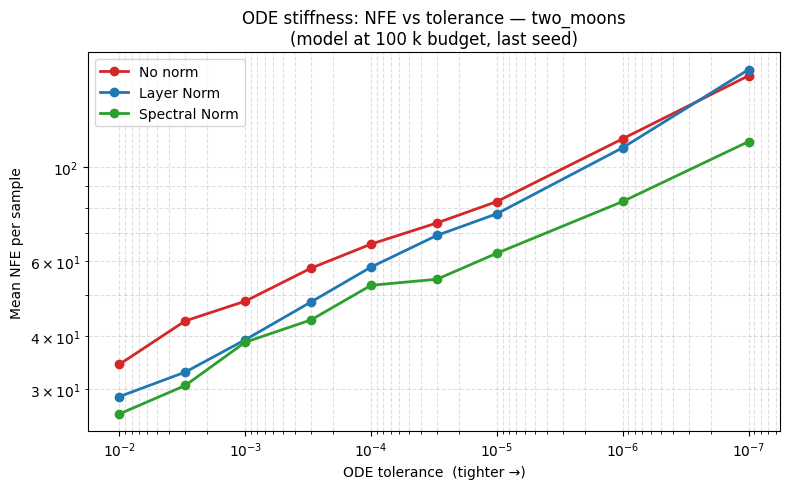

In [5]:
for task in TASKS:
    print(f"\n── {task} ──")
    plot_nfe_vs_tolerance_from_data(data[task]["nfe_tol"], task_name=task)


## 6 — Discussion

Spectral norm is theoretically motivated as bounding Lipschitz reduces ODE stiffness, but on small models/tasks it constrains expressiveness more than it regularizes. Moreover, at 100k simulation budget, Spectral norm didn't actually produce the smoothest vector field empirically it just produced the most constrained and least expressive one.

No-norm (benchmark) with loose tolerance (1e-3) achieves similar posterior quality and faster inference simultaneously. While the ability to add normalizations did not prove conclusive, the experiments demonstrated the value of the tolerance parameter in reducing the computational cost of inference for this method, which is particularly slow compared to previous methods of the type normalizing flow.